<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/supervised/Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compare 3 different classifiers in a robust way on the 4 datasets provided.

Use the Friedeman test performing a 5-time 2-fold cross validation for each classifier on each dataset.

Include the code and the report in a .zip archive and upload it.

In [160]:
from google.colab import drive
import scipy.io as sci
import sklearn
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import friedmanchisquare
import matplotlib.pyplot as plt
from scipy.stats import studentized_range
import itertools

In [2]:
# Connect to the drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [3]:
# dataset path
dataset_path = "/content/drive/MyDrive/Supervised/Datasets"

In [213]:
# get the first dataset
ds = sci.loadmat(f'{dataset_path}/dataset1.mat')
X_train_ds, X_test_ds, y_train_ds, y_test_ds = train_test_split(ds['data'], ds['labels'], test_size=0.2)

In [5]:
# train classifier in robust way
def train_robust_classifier(dataset=None, models=None, iteration=1):
  # prepare the dataset for training and testing
  accuracy = {name: [] for name in models.keys()}
  for ntimes in range(iteration):
    X_train, X_test, y_train, y_test = train_test_split(dataset['data'],
                                                        dataset['labels'],
                                                        test_size=0.5,
                                                        shuffle=True,
                                                        random_state=ntimes)
    # train in robust model way
    for name, model in models.items():
      model.fit(X_train, y_train.ravel())
      # predict on test dataset
      y_pred_test = model.predict(X_test)
      # get accuracy on test dataset
      accuracy[name].append(np.mean(y_pred_test == y_test.squeeze()))
      # reverse the training and testing proccess
      model.fit(X_test, y_test.ravel())
      y_pred_train = model.predict(X_train)
      accuracy[name].append(np.mean(y_pred_train == y_train.squeeze()))

  return accuracy

In [6]:
# Read and train multiple classifier on 4 different dataset
seed = 42
iteration = 5
def classifier_model(path=None, models=None):
  accuracy5x2 = []
  for i in range(1, 5):
    # Read the dataset
    dataset = sci.loadmat(file_name=f'{path}/dataset{i}.mat')
    # Train the model on the training dataset
    accuracy = train_robust_classifier(dataset, models, iteration)
    accuracy5x2.append(accuracy)
  return accuracy5x2

In [7]:
models = {
    'svm_lin': SVC(C=1.0, kernel='linear'),
    # 'svm_rbf': SVC(C=1.0, kernel='rbf'),
    'tree': DecisionTreeClassifier(criterion='gini', max_depth=20),
    'knn': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    }
accuracy5x2 = classifier_model(dataset_path, models=models)

In [8]:
# Create a summary table for each classifier on each dataset.
summary_table = []
headers = ['dataset', 'name', 'mean', 'std']
for i, accuracy in enumerate(accuracy5x2):
  for name, acc in accuracy.items():
    summary_table.append([f'D{i+1}', name, np.mean(acc), np.std(acc)])
summary_table = pd.DataFrame(summary_table, columns=headers)
summary_table

,dataset,name,mean,std
0,D1,svm_lin,1.000000,0.000000
1,D1,tree,0.990667,0.007424
2,D1,knn,1.000000,0.000000
3,D2,svm_lin,0.881333,0.017075
4,D2,tree,0.828667,0.022716
5,D2,knn,0.860667,0.015902
6,D3,svm_lin,0.666667,0.011353
7,D3,tree,0.900333,0.008622
8,D3,knn,0.920333,0.006046
9,D4,svm_lin,0.521333,0.050160


**Comparison Matrix for 4 datasets**

In [9]:
# Create comparison matrix
comparison_table = []
headers = ['Dataset', 'svm_lin', 'tree', 'knn']
for i, accuracy in enumerate(accuracy5x2):
  svm_lin_mean = np.mean(accuracy[headers[1]])
  tree_mean = np.mean(accuracy[headers[2]])
  knn_mean = np.mean(accuracy[headers[3]])

  comparison_table.append([f'D{i+1}', svm_lin_mean, tree_mean, knn_mean])
comparison_table = pd.DataFrame(comparison_table, columns=headers)
comparison_table

,Dataset,svm_lin,tree,knn
0,D1,1.000000,0.990667,1.000000
1,D2,0.881333,0.828667,0.860667
2,D3,0.666667,0.900333,0.920333
3,D4,0.521333,0.958333,0.958667


**Accuracy matrix**

In [153]:
accuracy_matrix = comparison_table.copy().drop(labels=["Dataset"], axis=1)
accuracy_matrix

,svm_lin,tree,knn
0,1.000000,0.990667,1.000000
1,0.881333,0.828667,0.860667
2,0.666667,0.900333,0.920333
3,0.521333,0.958333,0.958667


**Rank matrix**

In [154]:
# rank matrix
ranks_matrix = accuracy_matrix.rank(axis=1, ascending=False)
ranks_matrix

,svm_lin,tree,knn
0,1.5,3.0,1.5
1,1.0,3.0,2.0
2,3.0,2.0,1.0
3,3.0,2.0,1.0


**Average ranks**

In [155]:
# average rank
avg_ranks = ranks_matrix.mean()
avg_ranks

,0
svm_lin,2.125
tree,2.500
knn,1.375


**Computing Critical Difference (CD)**

>> k = number of algorithms

>> N = number of datasets

>> qα  = value from Nemenyi table

In [156]:
k = len(accuracy_matrix.columns)
N = len(accuracy_matrix)
alpha = 0.05
q_alpha = studentized_range.ppf(1-alpha, k, np.inf)

CD = q_alpha * np.sqrt((k*(k+1))/(6*N))
print(f' K: {k}\n N: {N} \n q_alpha: {q_alpha}\n CD: {CD}')

 K: 3
 N: 4 
 q_alpha: 3.314493155398122
 CD: 2.3437005863784095


**Nemenyi comparison**

In [157]:
algorithms = avg_ranks.index
nemenyi_matrix = pd.DataFrame(index=algorithms, columns=algorithms)

for i in algorithms:
    for j in algorithms:
        diff = abs(avg_ranks[i] - avg_ranks[j])
        nemenyi_matrix.loc[i,j] = diff

nemenyi_matrix

,svm_lin,tree,knn
svm_lin,0.0,0.375,0.75
tree,0.375,0.0,1.125
knn,0.75,1.125,0.0


**Plot Critical Difference Diagram**

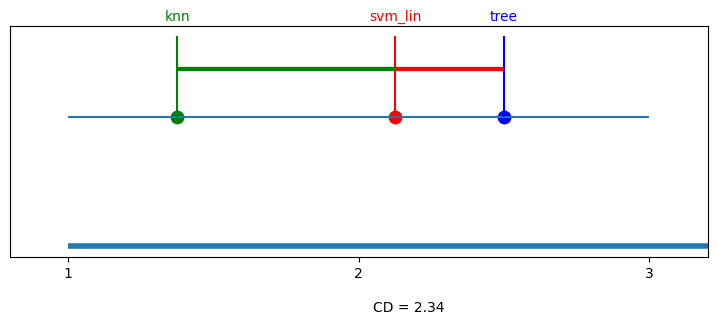

In [212]:
# sort algorithms by rank
sorted_alg = sorted(avg_ranks.items(), key=lambda x: x[1])
names = [a[0] for a in sorted_alg]
ranks = [a[1] for a in sorted_alg]
colors = {
    "svm_lin": "red",
    "tree": "blue",
    "knn": "green"
}
plt.figure(figsize=(9,3))

# main rank axis
plt.hlines(0,1,len(avg_ranks))
plt.xticks(range(1,len(avg_ranks)+1))
plt.yticks([])

# plot algorithms
for i,(name,rank) in enumerate(sorted_alg):
    c = colors[name]
    plt.scatter(rank,0, color=c, s=80)
    plt.vlines(rank,0,0.25, color=c)
    plt.text(rank, 0.3, name, ha="center", color=c)

# draw CD bar
plt.hlines(-0.4,1,1+CD,linewidth=4)
plt.text(1+CD/2, -0.6, f"CD = {CD:.2f}", ha="center")

# draw non-significant groups
for (a1,r1),(a2,r2) in itertools.combinations(sorted_alg,2):
    if abs(r1-r2) <= CD:
        plt.hlines(0.15, r1, r2, linewidth=3, color=colors[a1])

plt.xlim(0.8,len(avg_ranks)+0.2)
plt.show()

**Statistical comparison of algorithms**

A statistical comparison of the algorithms was conducted using the Friedman test followed by the Nemenyi post-hoc test at a significance level of α = 0.05.

The Critical Difference (CD) diagram shows that Knn has the best average rank and Tree the worst, but the differences between algorithms are smaller than the CD; therefore, no statistically significant difference is observed.

